# Prevendo Média de Público com Regressão Linear

### Nesse projeto construiremos um modelo de regressão linear para tentar prever a média de público de duas edições da copa do mundo.
### Como o banco de dados usados vai até a copa de 2014, podemos usar o modelo para estimar a média de público das copas subsequentes (2018, 2022) e coparar a previsão com os valores reais observados nessas copas.
### Como a média de público depende de muitos fatores que não seram considerados no modelo, como capacidade dos estádios e quantidade de times na competição. É esperado que a previsão não seja muito acurada, no entanto, considero que seja um bom exercício de regressão linear.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
copas = pd.read_csv('WorldCups.csv')

In [3]:
copas['Attendance'] = pd.to_numeric(copas['Attendance'].str.replace('.', ''))

In [4]:
copas['AverageAttendance'] = copas['Attendance'] / copas['MatchesPlayed']

In [5]:
X = copas[['Year']]
y = copas['AverageAttendance']

In [6]:
# Ajustar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[342.18]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.339e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
# Coeficientes
print('Intercepto:', modelo.intercept_)
print('Coeficiente:', modelo.coef_[0])

Intercepto: -633888.8233133222
Coeficiente: 342.1820817671543


In [8]:
# Previsões para próximas Copas
anos_futuros = pd.DataFrame({
    'Year': [2018, 2022]
})

previsoes = modelo.predict(anos_futuros)

for ano, media in zip(anos_futuros['Year'], previsoes):
    print(f'Previsão para {ano}:')
    print(f'{media:.0f} espectadores por partida.')

Previsão para 2018:
56635 espectadores por partida.
Previsão para 2022:
58003 espectadores por partida.


In [9]:
#Valores Reais
print('Média em 2018:')
print('47371 espectadores por partida.')
print('Média em 2022:')
print('53191 espectadores por partida.')

Média em 2018:
47371 espectadores por partida.
Média em 2022:
53191 espectadores por partida.


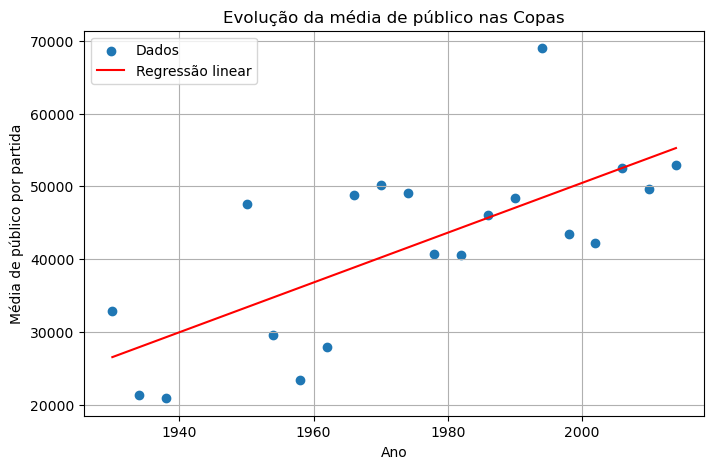

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(copas['Year'], copas['AverageAttendance'], label='Dados')
plt.plot(copas['Year'], modelo.predict(X), color='red', label='Regressão linear')

plt.xlabel("Ano")
plt.ylabel("Média de público por partida")
plt.title("Evolução da média de público nas Copas")
plt.legend()
plt.grid(True)

plt.show()

### Erro da previsão:

In [11]:
print(f'2018: {(previsoes[0] - 47371)*100/47371:.0f}%')
print(f'2022: {(previsoes[1] - 53191)*100/53191:.0f}%')

2018: 20%
2022: 9%


In [12]:
from sklearn.metrics import r2_score, mean_squared_error

pred = modelo.predict(X)

print('R²:', r2_score(y, pred))
print('RMSE:', np.sqrt(mean_squared_error(y, pred)))

R²: 0.49717066344504146
RMSE: 8580.7689941023


## Baseado no valor de R quadrado ligeramente menor do que 0.5 pode-se concluir que a regressão linear não é capaz de se compreender o comportamento da média de público.